<pre style="font-size: 15px; line-height: 1.2;">
---
course_code: 02BMSBI24365
course_title: AI and ML in Bioinformatics
institution: Garden City University (GCU)
program: M.Sc. Bioinformatics (Semester III)
unit: Unit 1 — Foundations of Machine Learning for Bioinformatics
submodule: 1.2 Data Preprocessing & Feature Engineering
document_type: Guided Lecture Notebook
ai_tier: Full AI (Learning Aid)
---


# 🧬 Data Transformations: Visualizing Problems & Solutions

## What is a Data Transformation?
A **Data Transformation** is the process of applying a mathematical function to numerical features to change their scale, center, or distribution shape. Its goal is to place different measurements onto a fair, comparable scale so that machine learning algorithms can analyze patterns accurately without being misled by raw numbers or differing units.

---

**Biological Context & Objective:**
In bioinformatics, biological variables naturally span vastly different physical units and biological scales.
If fed directly into machine learning algorithms (such as PCA, SVMs, or Neural Networks), the algorithm calculates distances and gradients dominated entirely by the large numbers, completely ignoring subtle but vital biological signals.

### In this guided notebook, we will:
1. **Expose the Scale Problem:** Inspect how raw scales distort Euclidean based ML algorithms.
2. **Implement & Visualize the 4 Core Transformations:**
   * **Log Transformation:** Taming heavily skewed sequencing counts ($\log_2(X + 1)$).
   * **Z-Score Standardization:** Centering continuous features around mean $0$ with standard deviation $1$.
   * **Min-Max Normalization:** Bounding features strictly between $0.0$ and $1.0$ (ideal for imaging pixels).
   * **Robust Scaling:** Centering and scaling with median and IQR to resist severe clinical outliers.
3. **Evaluate Diagnostic Visualizations:** Compare before vs. after distributions side by side.
4. **Student Challenge:** Clean and rescale an unstandardized multi-omics patient matrix.

## 1. Code Environment Setup
We import standard numerical and visualization libraries. We set a fixed random seed (`random_state=42`) to guarantee identical, reproducible outputs across runs.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Ensure reproducibility
np.random.seed(42)

# Configure clean aesthetic plot defaults
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 1.0


## 2. Why Numerical Features Require Transformation

Consider two routine clinical measurements recorded for an individual patient:
* **Age:** $45	\text{ years}$
* **Platelet count:** $250,000	\text{ cells/}\mu	\text{L}$

From a medical perspective, both values represent normal physiological findings. However, to a machine learning algorithm, these entries exist merely as raw numerical magnitudes. Because $250,000$ is orders of magnitude larger than $45$, distance-based algorithms and gradient-driven models will prioritize the platelet count, effectively ignoring patient age during model training.

```
Raw Data (Disproportionate)       ──>   Mathematical Transformation   ──>   Balanced Data
Age: 45                                 [Standardization / Scaling]         Age: +0.2
Platelets: 250,000                                                          Platelets: +0.4
(Algorithm overweights platelets)                                           (Both features contribute equally)
```

---
## 3. Log Transformation: Taming Runaway Skewness

### Definition & Concept
A **Log Transformation** replaces each number with its logarithm. In simple terms, it pulls giant numbers closer to the group so they don't overpower the small numbers.

### Intuitive Concept
Consider measuring individual wealth across a city. Most residents earn between $\$30,000$ and $\$80,000$ per year, but one resident is a multi-billionaire. Plotting these earnings on a standard linear scale compresses all ordinary salaries into an indistinguishable cluster near zero. A logarithmic transformation compresses the billionaire's value while preserving rank order, pulling extreme values closer so the remaining distribution can be analyzed.

### Biological Context & Application
In RNA sequencing ($\text{RNA-seq}$) and single-cell genomics, gene expression data is heavily right-skewed. Highly expressed structural genes (such as actin or ribosomal proteins) often register hundreds of thousands of sequencing reads, whereas regulatory transcription factors may only yield $5$ to $10$ reads.

> [!NOTE]
> **Assumption of Prior Biological Normalization:** We assume sequencing read counts are already adjusted for sequencing depth and library size (e.g., Counts Per Million [$\text{CPM}$]). The $\log_2(X + 1)$ step stabilizes variance for machine learning.

$$\text{Transformed Value} = \log_2(X + 1)$$

> **The Base 2 Convention in Biology:** Base 2 ($\log_2$) is standard in bioinformatics because a unit change of $+1.0$ corresponds directly to a **two-fold biological change** (doubling of gene expression), while a change of $-1.0$ represents a $50\%$ reduction (halving of expression).

Let us simulate $1,000$ gene expression measurements displaying an exponential distribution typical of RNA-seq data.

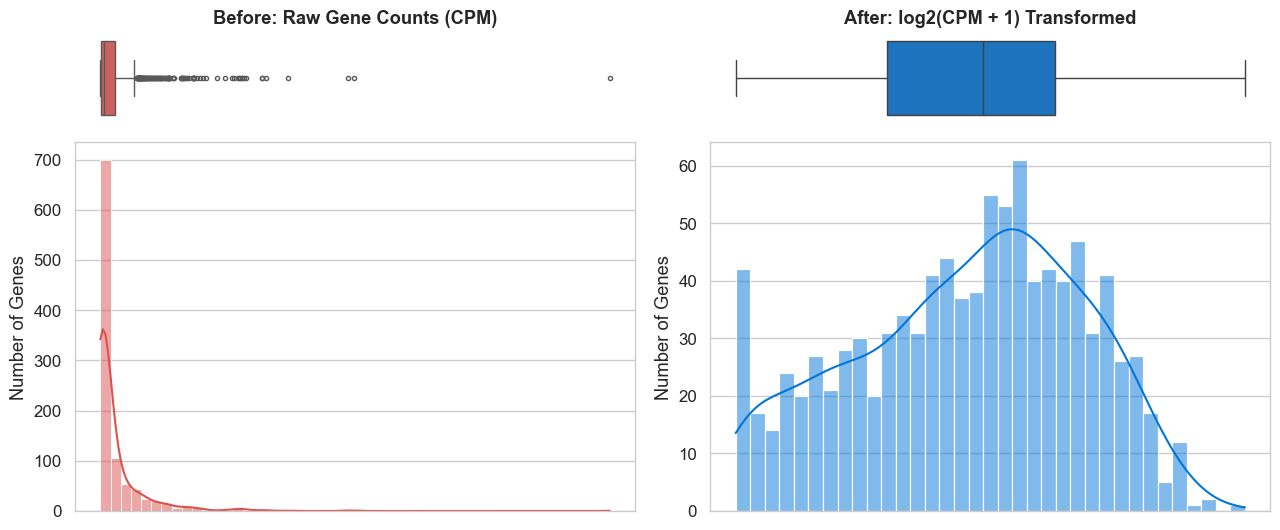

Raw CPM range:        [0.0, 15027.5]  --> Skewness: 6.48
log2(CPM + 1) range:  [0.0, 13.9]     --> Skewness: -0.27


In [ ]:
# Simulate realistic right-skewed CPM counts (mostly low, with a few reaching 5,000+)
raw_cpm = np.random.exponential(scale=15.0, size=1000) ** 2
raw_cpm = np.round(raw_cpm, 1)

# Apply log2(X + 1)
log2_cpm = np.log2(raw_cpm + 1.0) # -> Single line of code

## -------------------------------------------------------------
## -------------------------------------------------------------

# Side-by-side diagnostic visualization with marginal boxplots sharing x-axes
fig, axes = plt.subplots(2, 2, figsize=(13, 5.5), sharex="col", 
                         gridspec_kw={"height_ratios": [0.2, 0.8]})

# Top Left: Boxplot for Raw CPM (shows median/IQR crushed at zero, long outlier tail)
sns.boxplot(x=raw_cpm, ax=axes[0, 0], color="#d9534f", fliersize=3)
axes[0, 0].set(xlabel="", xticks=[])
axes[0, 0].set_title("Before: Raw Gene Counts (CPM)", fontweight="bold")
axes[0, 0].tick_params(left=False, labelleft=False)
sns.despine(ax=axes[0, 0], left=True, bottom=True)

# Bottom Left: Distribution curve (Histogram + KDE) for Raw CPM
sns.histplot(raw_cpm, bins=50, color="#d9534f", kde=True, ax=axes[1, 0])
axes[1, 0].set_xlabel("CPM (Severe Right Skew: Bulk near 0, runaway tail)")
axes[1, 0].set_ylabel("Number of Genes")

# Top Right: Boxplot for log2(CPM + 1) (shows median centered, balanced IQR)
sns.boxplot(x=log2_cpm, ax=axes[0, 1], color="#0275d8", fliersize=3)
axes[0, 1].set(xlabel="", xticks=[])
axes[0, 1].set_title("After: log2(CPM + 1) Transformed", fontweight="bold")
axes[0, 1].tick_params(left=False, labelleft=False)
sns.despine(ax=axes[0, 1], left=True, bottom=True)

# Bottom Right: Distribution curve (Histogram + KDE) for log2(CPM + 1)
sns.histplot(log2_cpm, bins=35, color="#0275d8", kde=True, ax=axes[1, 1])
axes[1, 1].set_xlabel("log2(CPM + 1) Scale (Values pulled in and balanced)")
axes[1, 1].set_ylabel("Number of Genes")

plt.tight_layout()
plt.subplots_adjust(hspace=0.08)
plt.show()

print(f"Raw CPM range:        [{raw_cpm.min():.1f}, {raw_cpm.max():.1f}]  --> Skewness: {pd.Series(raw_cpm).skew():.2f}")
print(f"log2(CPM + 1) range:  [{log2_cpm.min():.1f}, {log2_cpm.max():.1f}]     --> Skewness: {pd.Series(log2_cpm).skew():.2f}")

---
## 4. Z-Score Standardization: Zero-Centering & Variance Equalization

### Definition & Concept
**Standardization (Z-score scaling)** recalibrates a feature so that its average value becomes $0$ and its variation is measured in standard units. It calculates how far each measurement sits above or below the group average.

$$\text{Formula:}\quad Z = \frac{x - \mu}{\sigma}$$

### Intuitive Concept
Consider training a model on patient physical measurements where raw heights of males and females are grouped together into a single feature.

A raw measurement of **$175\text{ cm}$** carries very different biological implications depending on the group baseline:
* For an adult male cohort, $175\text{ cm}$ sits near the population average.
* For an adult female cohort, $175\text{ cm}$ represents an exceptionally tall, upper-percentile measurement.

If an algorithm evaluates only the raw number ($175\text{ cm}$), it measures absolute physical magnitude while missing how typical or extreme that value is for the individual's baseline population.

Standardization resolves this by converting raw numbers into standardized Z-scores:
* An observation exactly at the group average receives a value of **$0.0$**.
* An observation noticeably above average receives a **positive** score (e.g., $+2.0$).
* An observation below average receives a **negative** score (e.g., $-1.5$).

### Mixed-Cohort Intuition in Biology:
Consider two genes across a patient cohort:
* **Gene A (Structural housekeeping gene):** Mean expression $\approx 50,000\text{ counts}$ ($\sigma = 2,000$)
* **Gene B (Regulatory transcription factor):** Mean expression $\approx 20\text{ counts}$ ($\sigma = 4$)

If an oncological condition causes both genes to deviate by two standard deviations, the raw numerical increase is $4,000$ counts for Gene A and only $8$ counts for Gene B. Without standardization, distance-based models would track only Gene A. Standardizing gives both biological signals equal statistical standing.

Let us observe the distributions of Gene A and Gene B before and after standardization.

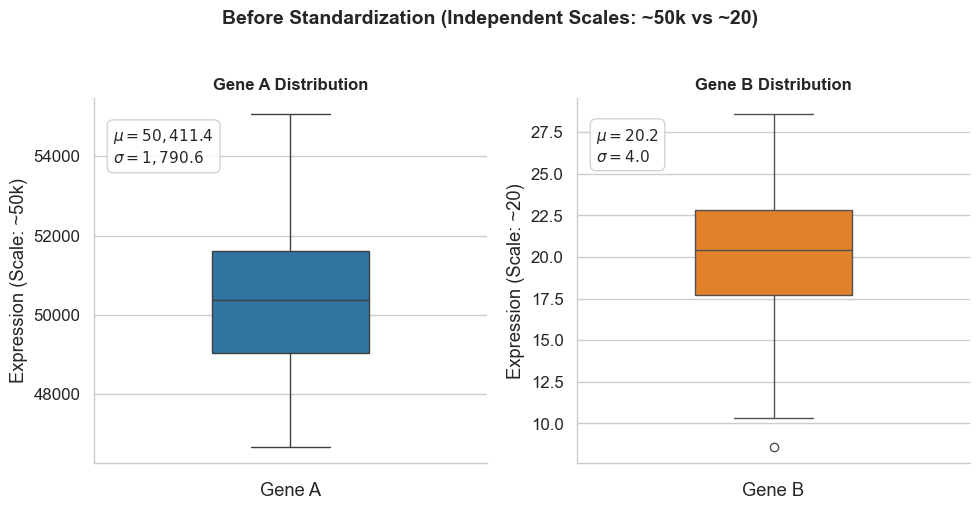

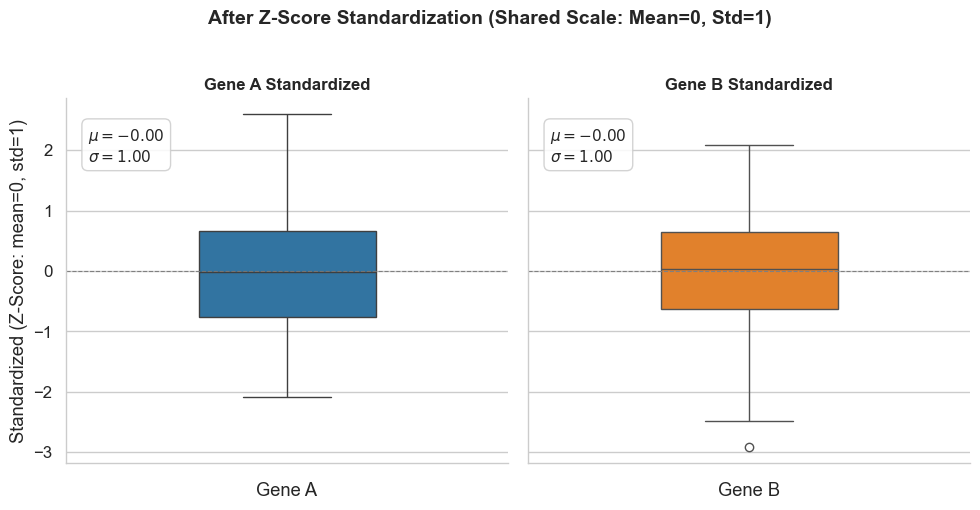

Original Means:             [5.04114e+04 2.02000e+01]
Standardized Means:         [-0. -0.] (Zero-centered)
Standardized Standard Devs: [1. 1.] (Unit variance)


In [87]:
# Simulate 150 patient samples for Gene A and Gene B
gene_A = np.random.normal(loc=50000, scale=2000, size=150)
gene_B = np.random.normal(loc=20, scale=4, size=150)
raw_genes = np.column_stack([gene_A, gene_B])

# -------------------------------------------------------------
# 1. BEFORE STANDARDIZATION (Independent Scales)
# -------------------------------------------------------------
# Create a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=False)

# Plot Gene A on the first subplot
sns.boxplot(y=gene_A, ax=ax1, color='#1f77b4', width=0.4)
ax1.set_title('Gene A Distribution', fontsize=12, weight='bold')
ax1.set_ylabel('Expression (Scale: ~50k)')
ax1.set_xlabel('Gene A')
ax1.text(0.05, 0.92, f"$\mu = {gene_A.mean():,.1f}$\n$\sigma = {gene_A.std():,.1f}$", 
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

# Plot Gene B on the second subplot
sns.boxplot(y=gene_B, ax=ax2, color='#ff7f0e', width=0.4)
ax2.set_title('Gene B Distribution', fontsize=12, weight='bold')
ax2.set_ylabel('Expression (Scale: ~20)')
ax2.set_xlabel('Gene B')
ax2.text(0.05, 0.92, f"$\mu = {gene_B.mean():.1f}$\n$\sigma = {gene_B.std():.1f}$", 
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

plt.suptitle('Before Standardization (Independent Scales: ~50k vs ~20)', fontsize=14, weight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 2. APPLY STANDARDSCALER
# -------------------------------------------------------------
scaler = StandardScaler()
std_genes = scaler.fit_transform(raw_genes)
std_gene_A = std_genes[:, 0]
std_gene_B = std_genes[:, 1]

# -------------------------------------------------------------
# 3. AFTER STANDARDIZATION (Shared Z-Score Scale)
# -------------------------------------------------------------
# Both genes can now share the exact same y-axis!
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# Plot Standardized Gene A
sns.boxplot(y=std_gene_A, ax=ax1, color='#1f77b4', width=0.4)
ax1.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax1.set_title('Gene A Standardized', fontsize=12, weight='bold')
ax1.set_ylabel('Standardized (Z-Score: mean=0, std=1)')
ax1.set_xlabel('Gene A')
ax1.text(0.05, 0.92, f"$\mu = {std_gene_A.mean():.2f}$\n$\sigma = {std_gene_A.std():.2f}$", 
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

# Plot Standardized Gene B
sns.boxplot(y=std_gene_B, ax=ax2, color='#ff7f0e', width=0.4)
ax2.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax2.set_title('Gene B Standardized', fontsize=12, weight='bold')
ax2.set_xlabel('Gene B')
ax2.text(0.05, 0.92, f"$\mu = {std_gene_B.mean():.2f}$\n$\sigma = {std_gene_B.std():.2f}$", 
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

plt.suptitle('After Z-Score Standardization (Shared Scale: Mean=0, Std=1)', fontsize=14, weight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

print("Original Means:            ", raw_genes.mean(axis=0).round(1))
print("Standardized Means:        ", std_genes.mean(axis=0).round(3), "(Zero-centered)")
print("Standardized Standard Devs:", std_genes.std(axis=0).round(3), "(Unit variance)")

---
## 5. Robust Scaling: Resisting Clinical Outlier Distortions

### Definition & Concept
**Robust Scaling** is an alternative way to scale data that relies on the **median** (the middle value) and the **interquartile range** (the middle $50\%$ of the data) rather than the arithmetic average and standard deviation. Because it ignores extreme edges, it does not get skewed by massive spikes or outliers.

### Intuitive Concept
Consider calculating the average exam mark for a class of ten students. If nine students score between $70\%$ and $80\%$, but one student mistakenly receives an entry of $1,000\%$, the arithmetic mean is pulled drastically upward, and the standard deviation explodes. In contrast, the median ($50\text{th}$ percentile) and the interquartile range (the middle $50\%$ of the cohort) remain stable. When datasets contain extreme, unremovable values, robust scaling rescales the majority of observations without allowing outliers to distort the scale.

$$\text{Formula:}\quad X_{\text{robust}} = \frac{x - \text{median}}{\text{IQR}} = \frac{x - Q_2}{Q_3 - Q_1}$$

### The Clinical Sepsis Scenario:
Serum C-reactive protein (CRP) typically ranges between $0.5$ and $3.0\text{ mg/L}$ in healthy patients, but spikes to $350.0\text{ mg/L}$ during acute bacterial sepsis. Let us compare `StandardScaler` vs. `RobustScaler` on this biomarker.

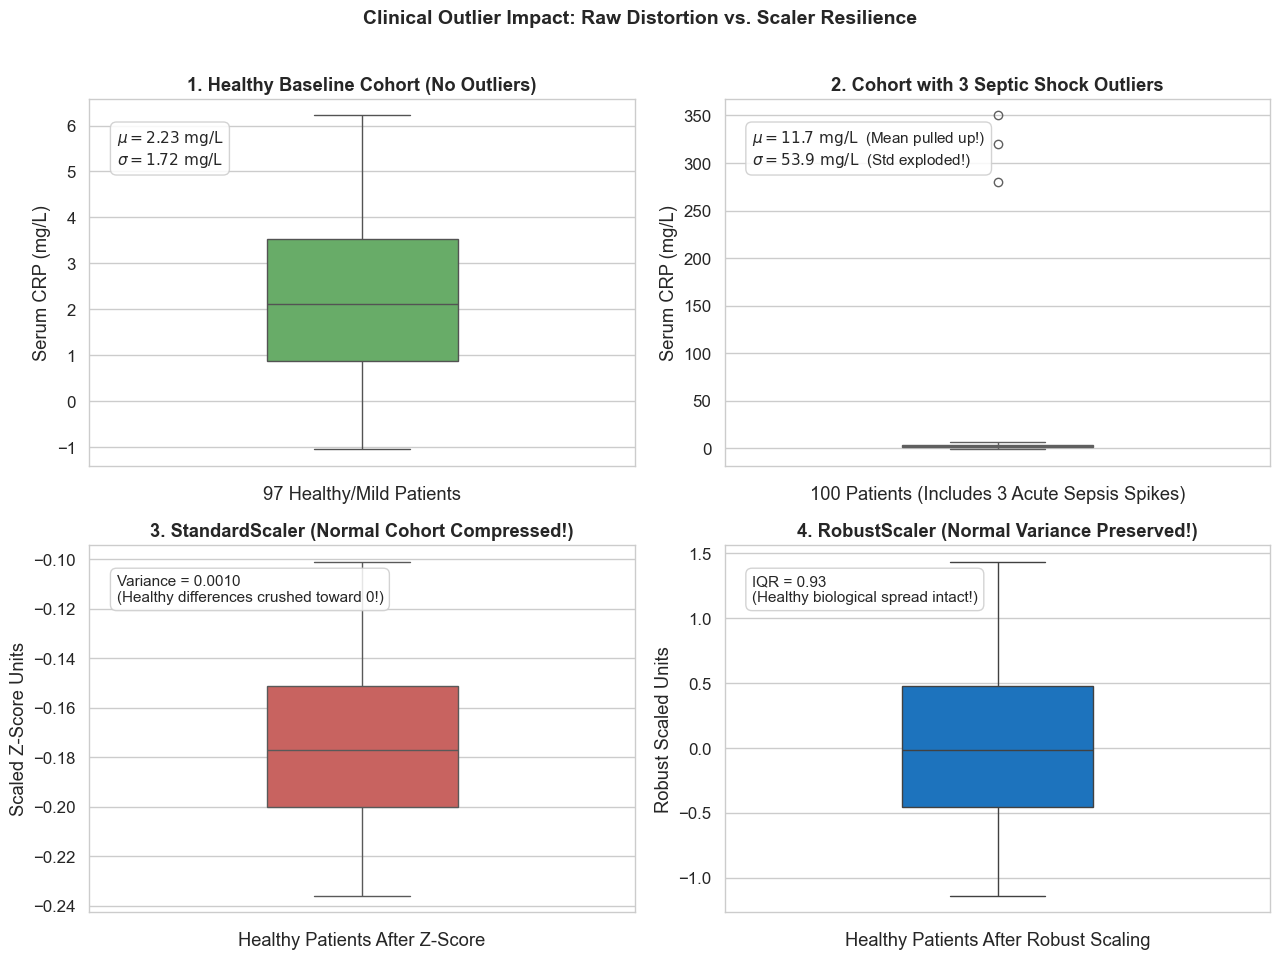

Original normal cohort mean:    2.23 mg/L | std: 1.72 mg/L
Cohort with outliers mean:      11.67 mg/L | std: 53.89 mg/L (Exploded!)
StandardScaler normal variance: 0.0010 (Crushed toward 0!)
RobustScaler normal IQR:         0.9336 (Healthy variation preserved!)


In [84]:
# Simulate 100 patient CRP readings: 97 healthy/mild patients, and 3 acute septic shock patients
normal_patients = np.random.normal(loc=2, scale=2, size=97)
septic_outliers = np.array([280.0, 320.0, 350.0])
crp_cohort = np.concatenate([normal_patients, septic_outliers]).reshape(-1, 1)

# Apply both scalers to the entire cohort
zscore_crp = StandardScaler().fit_transform(crp_cohort)
robust_crp = RobustScaler().fit_transform(crp_cohort)

# Create a 2x2 diagnostic figure
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))

# -------------------------------------------------------------
# ROW 1: THE RAW DATA PROBLEM (Impact of Outliers on Mean & Std)
# -------------------------------------------------------------
# Subplot (0, 0): Healthy cohort alone (without septic outliers)
sns.boxplot(y=normal_patients, ax=axes[0, 0], color="#5cb85c", width=0.35)
axes[0, 0].set_title("1. Healthy Baseline Cohort (No Outliers)", fontweight="bold")
axes[0, 0].set_ylabel("Serum CRP (mg/L)")
axes[0, 0].set_xlabel("97 Healthy/Mild Patients")
axes[0, 0].text(0.05, 0.92, f"$\mu = {normal_patients.mean():.2f}\\text{{ mg/L}}$\n$\sigma = {normal_patients.std():.2f}\\text{{ mg/L}}$", 
                transform=axes[0, 0].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

# Subplot (0, 1): Cohort with septic shock outliers added
sns.boxplot(y=crp_cohort.ravel(), ax=axes[0, 1], color="#f0ad4e", width=0.35)
axes[0, 1].set_title("2. Cohort with 3 Septic Shock Outliers", fontweight="bold")
axes[0, 1].set_ylabel("Serum CRP (mg/L)")
axes[0, 1].set_xlabel("100 Patients (Includes 3 Acute Sepsis Spikes)")
axes[0, 1].text(0.05, 0.92, f"$\mu = {crp_cohort.mean():.1f}\\text{{ mg/L}}$  (Mean pulled up!)\n$\sigma = {crp_cohort.std():.1f}\\text{{ mg/L}}$  (Std exploded!)", 
                transform=axes[0, 1].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

# -------------------------------------------------------------
# ROW 2: HOW OUTLIERS AFFECT Z-SCORE vs. ROBUST SCALING
# -------------------------------------------------------------
# Subplot (1, 0): StandardScaler applied (Z-Score of normal patients)
normal_zscore = zscore_crp[:97].ravel()
sns.boxplot(y=normal_zscore, ax=axes[1, 0], color="#d9534f", width=0.35)
axes[1, 0].set_title("3. StandardScaler (Normal Cohort Compressed!)", fontweight="bold")
axes[1, 0].set_ylabel("Scaled Z-Score Units")
axes[1, 0].set_xlabel("Healthy Patients After Z-Score")
axes[1, 0].text(0.05, 0.92, f"Variance = {normal_zscore.var():.4f}\n(Healthy differences crushed toward 0!)", 
                transform=axes[1, 0].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

# Subplot (1, 1): RobustScaler applied (Robust scaled normal patients)
normal_robust = robust_crp[:97].ravel()
robust_iqr = np.percentile(normal_robust, 75) - np.percentile(normal_robust, 25)
sns.boxplot(y=normal_robust, ax=axes[1, 1], color="#0275d8", width=0.35)
axes[1, 1].set_title("4. RobustScaler (Normal Variance Preserved!)", fontweight="bold")
axes[1, 1].set_ylabel("Robust Scaled Units")
axes[1, 1].set_xlabel("Healthy Patients After Robust Scaling")
axes[1, 1].text(0.05, 0.92, f"IQR = {robust_iqr:.2f}\n(Healthy biological spread intact!)", 
                transform=axes[1, 1].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

plt.suptitle("Clinical Outlier Impact: Raw Distortion vs. Scaler Resilience", fontsize=14, weight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Original normal cohort mean:    {normal_patients.mean():.2f} mg/L | std: {normal_patients.std():.2f} mg/L")
print(f"Cohort with outliers mean:      {crp_cohort.mean():.2f} mg/L | std: {crp_cohort.std():.2f} mg/L (Exploded!)")
print(f"StandardScaler normal variance: {normal_zscore.var():.4f} (Crushed toward 0!)")
print(f"RobustScaler normal IQR:         {robust_iqr:.4f} (Healthy variation preserved!)")

---
## 6. Min-Max Normalization: Bounding Values into [0, 1]

### Definition & Concept
**Min-Max Normalization** rescales all numbers in a feature so that they fit into a strict, bounded interval—most commonly between $0$ and $1$. The lowest value in the dataset becomes $0.0$, the highest value becomes $1.0$, and every other number falls proportionally in between.

### Intuitive Concept
Consider grading examinations that have different total point caps. One exam is graded out of $45$ points, while another is graded out of $100$ points. Min-Max normalization converts both score sets into a percentage scale from $0.0$ ($0\%$, lowest score) to $1.0$ ($100\%$, highest score), allowing direct mathematical comparison.

### Biological Context & Application
Min-Max normalization is primary in digital pathology, fluorescence microscopy, and medical imaging. Hardware detectors (such as whole-slide digital scanners) record light intensity on a fixed, bounded scale:
* An 8-bit image detector records pixel brightness strictly from $0$ (pure black) to $255$ (maximum light saturation).

Because physical light intensity cannot drop below zero or exceed sensor saturation, these values have known natural bounds and do not suffer from open-ended outliers. Bounding pixel arrays into the interval $[0.0, 1.0]$ ensures numerical stability when training artificial neural networks (such as Convolutional Neural Networks).

$$\text{Formula:}\quad X_{\text{norm}} = \frac{x - X_{\min}}{X_{\max} - X_{\min}}$$

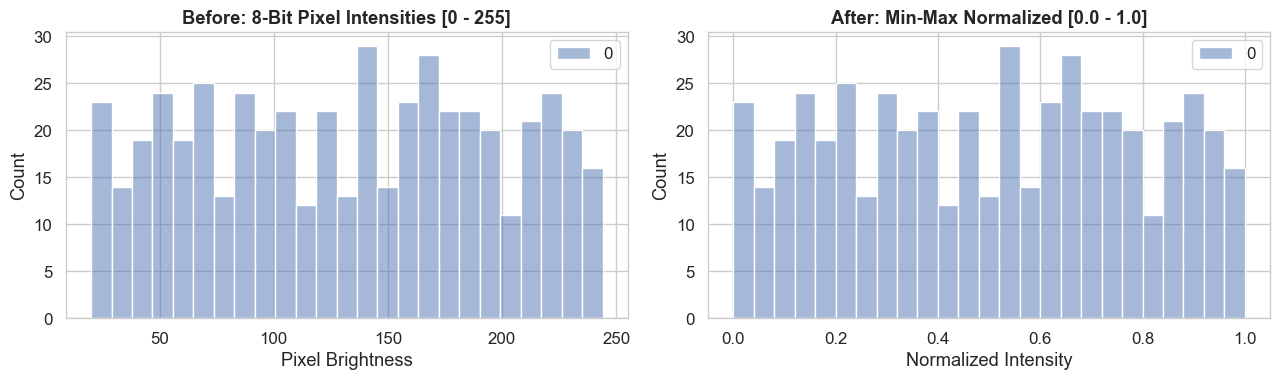

Original range:   [20, 244]
Normalized range: [0.00, 1.00]


In [ ]:
# Simulate an 8-bit digital pathology tile (pixel intensities 0 to 255)
raw_pixels = np.random.randint(low=20, high=245, size=500).reshape(-1, 1)

minmax_scaler = MinMaxScaler(feature_range=(0, 1))
normalized_pixels = minmax_scaler.fit_transform(raw_pixels)

# -------------------------------------------------------------
# -------------------------------------------------------------


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(raw_pixels, bins=25, color="#f0ad4e", ax=axes[0])
axes[0].set_title("Before: 8-Bit Pixel Intensities [0 - 255]", fontweight="bold")
axes[0].set_xlabel("Pixel Brightness")
axes[0].set_ylabel("Count")

sns.histplot(normalized_pixels, bins=25, color="#5cb85c", ax=axes[1])
axes[1].set_title("After: Min-Max Normalized [0.0 - 1.0]", fontweight="bold")
axes[1].set_xlabel("Normalized Intensity")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Original range:   [{raw_pixels.min()}, {raw_pixels.max()}]")
print(f"Normalized range: [{normalized_pixels.min():.2f}, {normalized_pixels.max():.2f}]")


---
## 7. Decision Framework: Selecting the Appropriate Method
### Two-Step Decision Logic

* **Decision 1 — Distribution:** Does the downstream method need a particular distribution?
  * **If Yes:** Transform shape (e.g., $\log_2(X + 1)$ on right-skewed RNA-seq read counts).
  * **If No:** Proceed directly to scale check.
* **Decision 2 — Scale:** Does the downstream method care about feature scale?
  * **If No:** Don't scale (e.g., Decision Trees, Random Forests, Gradient Boosted Trees / XGBoost).
  * **If Yes:** Choose based on data characteristics:
    * *Outliers are a concern:* `RobustScaler` (e.g., $k$-NN, distance metrics, or linear classifiers on clinical panels with acute inflammation spikes like CRP).
    * *No major outliers:* `StandardScaler` (e.g., PCA projections, Support Vector Machines, Logistic Regression, $K$-Means clustering).
    * *Specifically need bounded range:* `MinMaxScaler` (e.g., Artificial Neural Networks, CNNs processing 8-bit digital pathology images $[0, 255]$, flow cytometry channels).

---
## 🧪 Student Challenge: Multi-Omics Patient Matrix Preparation

**Scenario:** You have received a multi-omics feature table for 6 patients (`raw_cohort_matrix`). Each column represents a distinct biological measurement recorded on an unstandardized scale:
1. `RNA_Gene_Count`: Highly skewed CPM read count from an RNA-seq run.
2. `Serum_CRP_mg_L`: A systemic inflammation marker with an acute clinical spike.
3. `Biopsy_Tile_Intensity`: Mean grayscale pixel brightness from a biopsy scanner ($0$ to $255$).
4. `Hemoglobin_g_dL`: A continuous, normally distributed clinical blood marker.

### Your Task:
Apply the correct transformation to each individual column:
* Apply $\\log_2(X + 1)$ to `RNA_Gene_Count` using `np.log2()`.
* Apply `RobustScaler` to `Serum_CRP_mg_L`.
* Apply `MinMaxScaler` to `Biopsy_Tile_Intensity`.
* Apply `StandardScaler` to `Hemoglobin_g_dL`.

Store all transformed features in a clean DataFrame named `transformed_cohort_matrix` and display it.


In [91]:
# Raw unstandardized multi-omics clinical cohort
raw_cohort_matrix = pd.DataFrame({
    "Patient_ID": ["PT_01", "PT_02", "PT_03", "PT_04", "PT_05", "PT_06"],
    "RNA_Gene_Count": [2.0, 15.0, 0.0, 511.0, 4.0, 2047.0],
    "Serum_CRP_mg_L": [1.2, 2.0, 0.8, 340.0, 1.9, 1.4],
    "Biopsy_Tile_Intensity": [32.0, 128.0, 240.0, 16.0, 192.0, 64.0],
    "Hemoglobin_g_dL": [14.2, 12.8, 15.1, 13.6, 14.8, 11.9]
})

print("--- Raw Multi-Omics Cohort Matrix ---")
display(raw_cohort_matrix)

# ==========================================================
# STUDENT CHALLENGE: IMPLEMENT YOUR TRANSFORMATIONS BELOW
# ==========================================================
transformed_cohort_matrix = raw_cohort_matrix.copy()

# 1. Transform RNA_Gene_Count using log2(X + 1)
# transformed_cohort_matrix["RNA_Gene_Count"] = ...

# 2. Transform Serum_CRP_mg_L using RobustScaler
# transformed_cohort_matrix[["Serum_CRP_mg_L"]] = ...

# 3. Transform Biopsy_Tile_Intensity using MinMaxScaler
# transformed_cohort_matrix[["Biopsy_Tile_Intensity"]] = ...

# 4. Transform Hemoglobin_g_dL using StandardScaler
# transformed_cohort_matrix[["Hemoglobin_g_dL"]] = ...

# Display the final transformed table
# display(transformed_cohort_matrix)


--- Raw Multi-Omics Cohort Matrix ---


,Patient_ID,RNA_Gene_Count,Serum_CRP_mg_L,Biopsy_Tile_Intensity,Hemoglobin_g_dL
0,PT_01,2.0,1.2,32.0,14.2
1,PT_02,15.0,2.0,128.0,12.8
2,PT_03,0.0,0.8,240.0,15.1
3,PT_04,511.0,340.0,16.0,13.6
4,PT_05,4.0,1.9,192.0,14.8
5,PT_06,2047.0,1.4,64.0,11.9
